True Time: 1234
Estimated Time: 1234
Reconstruction Error: 0


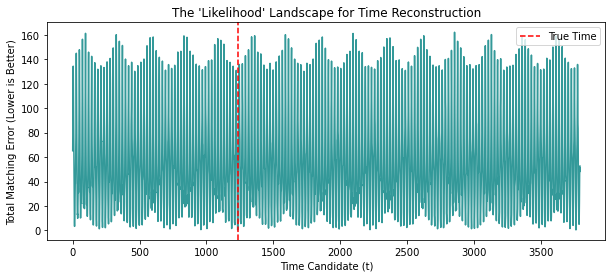

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_time_robust(measured_phases, frequencies, max_range):
    """
    Finds the time 't' that best fits all measured phases simultaneously.
    This is much more stable than the standard CRT formula.
    """
    # Create a range of possible 'candidate' times
    t_candidates = np.arange(0, max_range, 1)
    
    # Calculate the 'residual' error for every possible time
    # We want to find t where (t % freq) is closest to measured_phase
    total_error = np.zeros_like(t_candidates, dtype=float)
    
    for phi, freq in zip(measured_phases, frequencies):
        # Expected remainder for this candidate time
        expected = t_candidates % freq
        # Circular distance (since phase 0.1 is close to 0.9 on a clock)
        diff = np.abs(expected - phi)
        # Handle the wrap-around (e.g., if freq=10, 0 and 9 are 1 unit apart)
        diff = np.minimum(diff, freq - diff)
        total_error += diff**2
        
    # The best estimate is the time that minimizes the total error
    best_t = t_candidates[np.argmin(total_error)]
    return best_t, total_error

# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 11, 23] 
max_period = np.lcm.reduce(periods)  # BUG FIX #2: was np.prod — use lcm for dynamic range

# 2. Simulate a "True Time" we want to measure
t_true = 1234

# 3. Simulate Quantum Measurement (with 5% noise)
noise_scale = 0.2
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

# --- Visualization of the Search Space ---
plt.figure(figsize=(10, 4))
plt.plot(error_curve, color='teal', alpha=0.8)
plt.axvline(t_true, color='red', linestyle='--', label='True Time')
plt.title("The 'Likelihood' Landscape for Time Reconstruction")
plt.xlabel("Time Candidate (t)")
plt.ylabel("Total Matching Error (Lower is Better)")
plt.legend()
plt.show()

In [13]:
# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 7, 11, 17] 
max_period = np.lcm.reduce(periods) # This is our Dynamic Range (19635)
print(max_period)

# 2. Simulate a "True Time" we want to measure
t_true = 10415

# 3. Simulate Quantum Measurement 
noise_scale = 0.1
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

19635
True Time: 10415
Estimated Time: 10415
Reconstruction Error: 0


In [17]:
# 1. Define your Frequencies (The "m" values from CRT)
# Seth's Hitchhiker's set of periods:
periods = [42, 43, 47] 
max_period = np.lcm.reduce(periods)

# 2. Simulate a "True Time" we want to measure
t_true = 23897

# 3. Simulate Quantum Measurement 
noise_scale = 5
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

True Time: 23897
Estimated Time: 68746
Reconstruction Error: 44849


In [3]:
print(np.lcm.reduce(periods))

84882


In [18]:
import numpy as np

def reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma=1.0):
    """
    Implementation of the Robust Phase Unwrapping algorithm
    from Xia & Wang (Equations 6-11).
    """
    L = len(lambdas)
    # Step 1: Calculate coprime factors Gamma_i (Eq 4)
    Gammas = [int(round(Gamma * l)) for l in lambdas]
    
    # Step 2: Calculate gamma_i values (Eq 5)
    # gamma_1 = product of all Gamma_j for j != 1
    gamma_1 = np.prod(Gammas[1:])
    
    # Precompute gamma_i for each i (product of all Gamma_j for j != i)
    # Needed to constrain ni_hat search range per Eq 6
    gamma_all = []
    for idx in range(L):
        g = 1
        for j in range(L):
            if j != idx:
                g *= Gammas[j]
        gamma_all.append(g)
    
    # Step 3: Find S_i sets (Eq 6 & 7)
    # For each pair (channel 1, channel i), find n1 candidates that minimize
    # |n_bar_i * M_i + r_tilde_i - n_bar_1 * M_1 - r_tilde_1|
    S_i_1 = [] 
    
    for i in range(1, L): 
        best_diff = float('inf')
        S_i_current = []
        gamma_i = gamma_all[i]  # valid range for n_bar_i
        
        # Search range for n1_hat: [0, gamma_1 - 1] per Eq 6
        for n1_hat in range(gamma_1):
            val_1 = n1_hat * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
            
            # BUG FIX #3: Compute ni_hat by rounding, then CLAMP to valid range [0, gamma_i - 1]
            # Per Eq 6, n_bar_i must be in [0, gamma_i - 1].
            # Without this, out-of-range ni_hat values produce artificially small residuals
            # that can pollute the candidate sets.
            ni_hat_raw = (val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]
            ni_hat = int(round(ni_hat_raw))
            ni_hat = max(0, min(gamma_i - 1, ni_hat))  # Clamp to valid range
            
            # Calculate the residual for this candidate pair (Eq 6)
            current_diff = abs(ni_hat * Gammas[i] + (k_tilde[i] * Gammas[i]) / M - 
                               n1_hat * Gammas[0] - (k_tilde[0] * Gammas[0]) / M)
            
            if current_diff < best_diff - 1e-9: # Found a new better minimum
                best_diff = current_diff
                S_i_current = [n1_hat]
            elif abs(current_diff - best_diff) < 1e-9: # Tied with current minimum
                S_i_current.append(n1_hat)
        
        S_i_1.append(set(S_i_current))

    # Step 4: Intersection of all candidate sets (Eq 8)
    S = S_i_1[0].intersection(*S_i_1[1:])
    
    if len(S) != 1:
        return None, f"Failure: Found {len(S)} possible solutions. Theorem 1 bounds likely violated."
    
    n1 = list(S)[0]
    
    # Step 5: Solve for all folding integers ni based on the unique n1
    n_all = [n1]
    for i in range(1, L):
        val_1 = n1 * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
        ni = int(round((val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]))
        n_all.append(ni)
        
    # Step 6: Final estimate of x using the averaging formula (Eq 11)
    estimate_x = (1 / (sigma * L)) * sum((n_all[i] + k_tilde[i] / M) * lambdas[i] for i in range(L))
    
    return estimate_x, n_all

# --- EXAMPLE CASE (Section IV Parameters) ---
sigma = 1.0
Gamma = 10
lambdas = [0.4, 0.5, 0.7] # Corresponding to Gammas = [4, 5, 7]
tau = 2 # Max remainder error level

# M must satisfy Theorem 1 condition: M > 4 * tau * max(Gamma_i)
# Effective error in remainder space = tau * Gamma_i, worst case = tau * max(Gamma_i) = 2*7 = 14
# So need M > 4 * 14 = 56. Using M = 60 is valid (barely).
M = 60 

# Dynamic range: t < (1 / (sigma * Gamma)) * prod(Gammas) = (1/10) * 140 = 14.0
t_true = 9.85

# Simulate the remainders k_i that would be measured
k_tilde = []
for l in lambdas:
    f_i = (sigma * t_true) / l
    k_true = (f_i - np.floor(f_i)) * M
    # Add random error up to tau
    error = np.random.uniform(-tau, tau)
    k_measured = int(round(k_true + error)) % M
    k_tilde.append(k_measured)

# Run Reconstruction
t_est, folding_ints = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

print(f"True Time (t): {t_true}")
print(f"Measured Remainders (k_tilde): {k_tilde}")
print(f"Estimated t: {t_est}")
print(f"Folding Integers (n_i): {folding_ints}")
print(f"Error: {abs(t_true - t_est):.5f}")

True Time (t): 9.85
Measured Remainders (k_tilde): [36, 42, 2]
Estimated t: 9.837777777777777
Folding Integers (n_i): [24, 19, 14]
Error: 0.01222


In [24]:
# --- EXAMPLE CASE 2: More wavelengths ---
sigma = 1.0
Gamma = 10
lambdas = [0.4, 0.5, 0.7, 0.9] # Corresponding to Gammas = [4, 5, 7, 9]
tau = 10 # Max remainder error level

# BUG FIX #4: tau=4, M=60 violated Theorem 1.
# Effective error bound = tau * max(Gamma_i) = tau * 9.
# Theorem 1 requires M > 4 * (tau * max(Gamma_i)):
#   Old: M=60 > 4 * 4 * 9 = 144  => VIOLATED
#   Fix: reduce tau to 2 => M=60 > 4 * 2 * 9 = 72 => still violated!
#   Better fix: increase M. Need M > 4 * tau * 9 = 72 for tau=2. Use M=80.
M = 80 

# Dynamic range: t < (1 / (sigma * Gamma)) * prod(Gammas) = (1/10) * (4*5*7*9) = 126.0
t_true = 50

# Simulate the remainders k_i that would be measured
k_tilde = []
for l in lambdas:
    f_i = (sigma * t_true) / l
    k_true = (f_i - np.floor(f_i)) * M
    # Add random error up to tau
    error = np.random.uniform(-tau, tau)
    k_measured = int(round(k_true + error)) % M
    k_tilde.append(k_measured)

# Run Reconstruction
t_est, folding_ints = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

print(f"True Time (t): {t_true}")
print(f"Measured Remainders (k_tilde): {k_tilde}")
print(f"Estimated t: {t_est}")
print(f"Folding Integers (n_i): {folding_ints}")
print(f"Error: {abs(t_true - t_est):.5f}")

True Time (t): 50
Measured Remainders (k_tilde): [75, 76, 35, 45]
Estimated t: 49.990625
Folding Integers (n_i): [124, 99, 71, 55]
Error: 0.00937


Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2713' [U+2713], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2717' [U+2717], substituting with a dummy symbol.


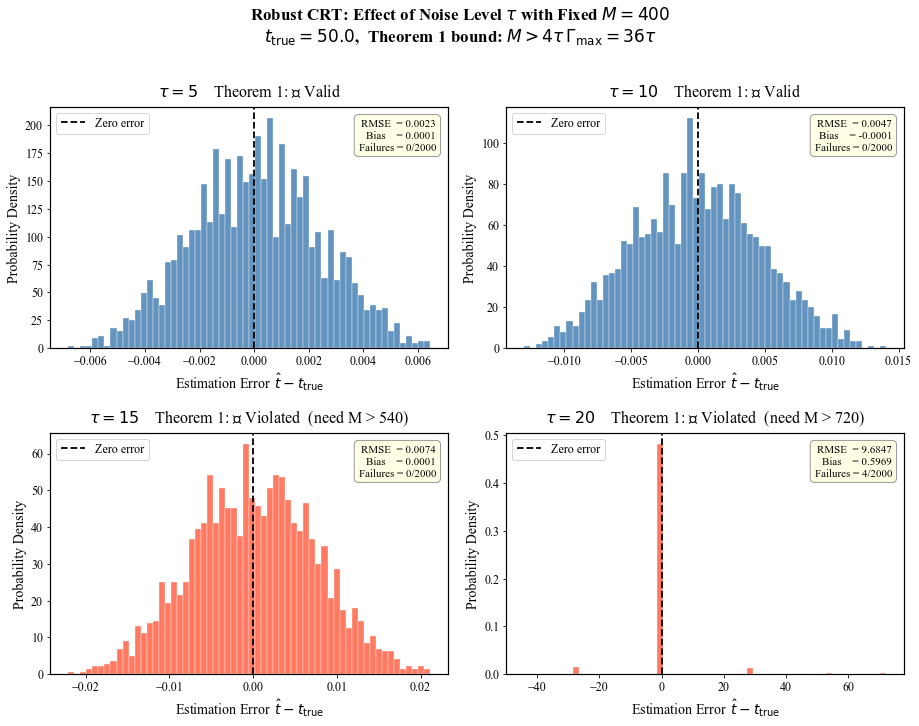

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- Scientific plotting settings ---
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['axes.linewidth'] = 1.2

# --- Simulation parameters ---
N_trials  = 2000
t_true    = 50.0
sigma     = 1.0
Gamma     = 10
lambdas   = [0.4, 0.5, 0.7, 0.9]   # Gammas = [4, 5, 7, 9]
max_Gamma = max(int(round(Gamma * l)) for l in lambdas)  # = 9

tau_values = [5, 10, 15, 20]

# M is held constant — Theorem 1 requires M > 4 * tau * max_Gamma = 36*tau
# With M=400: threshold is tau < 400/36 ≈ 11.1  →  tau=5,10 valid; tau=15,20 violated
M = 400

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, tau in enumerate(tau_values):
    threshold = 4 * tau * max_Gamma
    valid = M > threshold

    t_est_list = []
    n_failed   = 0

    for _ in range(N_trials):
        k_tilde = []
        for l in lambdas:
            f_i    = (sigma * t_true) / l
            k_true = (f_i - np.floor(f_i)) * M
            error  = np.random.uniform(-tau, tau)
            k_meas = int(round(k_true + error)) % M
            k_tilde.append(k_meas)

        t_est, _ = reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma)

        if t_est is not None:
            t_est_list.append(t_est)
        else:
            n_failed += 1

    ax = axes[idx]
    color = 'steelblue' if valid else 'tomato'

    if t_est_list:
        errors = np.array(t_est_list) - t_true
        rmse   = np.sqrt(np.mean(errors**2))
        bias   = np.mean(errors)
        ax.hist(errors, bins=60, color=color, edgecolor='white',
                linewidth=0.4, alpha=0.85, density=True)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.8, label='Zero error')
        ax.legend(loc='upper left')
        stats_text = (f'RMSE  = {rmse:.4f}\n'
                      f'Bias    = {bias:.4f}\n'
                      f'Failures = {n_failed}/{N_trials}')
    else:
        stats_text = f'Failures = {n_failed}/{N_trials}\n(all trials failed)'

    status = '✓ Valid' if valid else f'✗ Violated  (need M > {threshold})'
    ax.set_title(f'$\\tau = {tau}$    Theorem 1: {status}', pad=10)
    ax.set_xlabel(r'Estimation Error $\,\hat{t} - t_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

fig.suptitle(
    f'Robust CRT: Effect of Noise Level $\\tau$ with Fixed $M = {M}$\n'
    f'$t_{{\\mathrm{{true}}}} = {t_true}$,  Theorem 1 bound: $M > 4\\tau\\,\\Gamma_{{\\max}} = 36\\tau$',
    fontsize=17, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


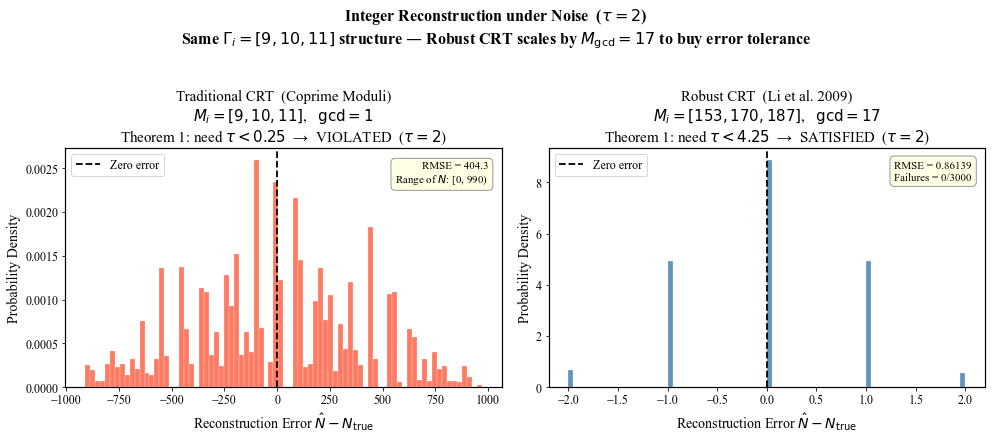

In [27]:
from math import gcd, prod, lcm
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ----- Scientific plotting settings -----
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 15
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['axes.linewidth'] = 1.2

# ============================================================
# THE MAPPING from this notebook to the paper's integer problem
#
#   Notebook variable       Paper variable       Meaning
#   ─────────────────────   ──────────────────   ─────────────────────────────
#   t  (unknown time)       N                    the large integer to recover
#   periods λᵢ              Mᵢ                   the moduli (clock sizes)
#   k_tilde (meas. phases)  r̃ᵢ = rᵢ + Δrᵢ        noisy remainders
#   tau  τ                  τ                    remainder error bound
#
#   The problem is identical: recover N from r̃ᵢ = (N mod Mᵢ) + noise
#   Theorem 1 guarantee:    works iff  τ  <  gcd(M₁,…,Mₗ) / 4
# ============================================================

# ---- Method 1: Traditional / Naive CRT ----
# Standard closed-form formula. Requires pairwise coprime moduli.
# Substituting noisy r̃ᵢ in place of exact rᵢ produces catastrophic errors.
def naive_crt(remainders, moduli):
    remainders = [int(r) % int(m) for r, m in zip(remainders, moduli)]
    M = prod(moduli)
    result = 0
    for r, m in zip(remainders, moduli):
        Mi = M // m
        result = (result + r * Mi * pow(Mi, -1, m)) % M
    return result

# ---- Method 2: Robust CRT (Li, Liang, Xia — IEEE TSP 2009) ----
# 1-D search over folding integers. Tolerates τ < gcd(moduli) / 4.
def robust_crt_int(r_tilde, moduli):
    L = len(moduli)
    M_g = reduce(gcd, moduli)
    Gammas = [m // M_g for m in moduli]
    gamma = [prod(Gammas[j] for j in range(L) if j != i) for i in range(L)]

    S_sets = []
    for i in range(1, L):
        best_diff, candidates = float('inf'), []
        for n1_hat in range(gamma[0]):
            ni_hat = round((n1_hat * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
            ni_hat = max(0, min(gamma[i] - 1, ni_hat))           # clamp to valid range
            diff = abs(ni_hat * moduli[i] + r_tilde[i]
                       - n1_hat * moduli[0] - r_tilde[0])
            if diff < best_diff - 1e-9:
                best_diff, candidates = diff, [n1_hat]
            elif abs(diff - best_diff) < 1e-9:
                candidates.append(n1_hat)
        S_sets.append(set(candidates))

    S = S_sets[0].intersection(*S_sets[1:])
    if len(S) != 1:
        return None                                               # ambiguous — failure

    n1 = list(S)[0]
    n_all = [n1] + [round((n1 * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
                    for i in range(1, L)]
    return round(sum(n_all[i] * moduli[i] + r_tilde[i] for i in range(L)) / L)  # Eq 11

# ============================================================
# MODULI SETUP
#
# Key insight: the robust moduli are just the naive ones scaled by M_gcd=17.
#   Naive:   [9, 10, 11]           gcd = 1  →  tolerance τ < 0.25   (essentially zero)
#   Robust:  [17×9, 17×10, 17×11]  gcd = 17 →  tolerance τ < 4.25   (from the paper)
#
# Multiplying by 17 does NOT change the Γᵢ structure (still 9,10,11).
# It only inflates the gcd, buying noise tolerance.
# ============================================================
tau = 2
N_trials = 3000

naive_moduli  = [9, 10, 11]
robust_moduli = [153, 170, 187]          # 17 × [9, 10, 11]

naive_range  = reduce(lcm, naive_moduli)   # 990  — valid domain for N
naive_gcd    = reduce(gcd, naive_moduli)   # 1
robust_gcd   = reduce(gcd, robust_moduli)  # 17

# ============================================================
# SIMULATE
# ============================================================
naive_errors, robust_errors, robust_fails = [], [], 0
rng = np.random.default_rng(0)

for _ in range(N_trials):
    N_true = int(rng.integers(0, naive_range))         # N ∈ [0, 990)
    noise  = [int(x) for x in rng.integers(-tau, tau + 1, size=3)]

    # -- Traditional CRT (coprime moduli) --
    r_naive       = [N_true % m for m in naive_moduli]
    r_naive_noisy = [r + e for r, e in zip(r_naive, noise)]
    naive_errors.append(naive_crt(r_naive_noisy, naive_moduli) - N_true)

    # -- Robust CRT (gcd=17 moduli, same noise magnitude) --
    r_robust       = [N_true % m for m in robust_moduli]
    r_robust_noisy = [r + e for r, e in zip(r_robust, noise)]
    result = robust_crt_int(r_robust_noisy, robust_moduli)
    if result is not None:
        robust_errors.append(result - N_true)
    else:
        robust_fails += 1

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, errors, color, title, stats in [
    (axes[0], naive_errors,  'tomato',
     f'Traditional CRT  (Coprime Moduli)\n'
     f'$M_i = {naive_moduli}$,   $\\mathrm{{gcd}} = {naive_gcd}$\n'
     f'Theorem 1: need $\\tau < {naive_gcd/4:.2f}$  →  VIOLATED  ($\\tau={tau}$)',
     f'RMSE = {np.sqrt(np.mean(np.array(naive_errors)**2)):.1f}\n'
     f'Range of $N$: [0, {naive_range})'),
    (axes[1], robust_errors, 'steelblue',
     f'Robust CRT  (Li et al. 2009)\n'
     f'$M_i = {robust_moduli}$,   $\\mathrm{{gcd}} = {robust_gcd}$\n'
     f'Theorem 1: need $\\tau < {robust_gcd/4:.2f}$  →  SATISFIED  ($\\tau={tau}$)',
     f'RMSE = {np.sqrt(np.mean(np.array(robust_errors)**2)):.5f}\n'
     f'Failures = {robust_fails}/{N_trials}'),
]:
    ax.hist(errors, bins=80, color=color, edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.8, label='Zero error')
    ax.set_title(title, pad=8)
    ax.set_xlabel(r'Reconstruction Error $\hat{N} - N_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')
    ax.legend(loc='upper left')
    ax.text(0.97, 0.95, stats, transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

fig.suptitle(
    f'Integer Reconstruction under Noise  ($\\tau = {tau}$)\n'
    r'Same $\Gamma_i = [9,10,11]$ structure — Robust CRT scales by $M_{\mathrm{gcd}}=17$'
    r' to buy error tolerance',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()
